In [153]:
import numpy as np
import matplotlib.pyplot as plt
import itertools as it
import seaborn as sns

from ipywidgets import IntProgress
from IPython.display import display

In [21]:
def normalize(arr, axis=0):
    normalization_factor = np.sum(arr, axis, keepdims=True)
    return arr / normalization_factor

# Basic model for joint inference of word order and reference

## Description of experimental setup

- 7 'referents':
    - 4 beings
    - 3 transitive actions
- 7 words
    - One for each referent
- Hypotheses 
    - Hypothesis space is the space of languages
    - Each language consists of a lexical interpretation function and a grammar (word order)
    - Interpretation function attributes one meaning to each word. There's 7! many of them (5040)
    - Grammar is just one of 6 possible word orders
    - Total of 30240 possible languages
- Priors
    - Possibly prior preference for some word orders
    - No prior knowledge about which words refer to which referents
    - I think it's reasonable to assume that the participant thinks that the interpretation function is a bijection (i.e. no homonymy or synonymy)
- Data:
    - Each observation consists of:
    - 4 scenes (each consisting of one agent, one patient, and one transitive action)
    - 1 utterance
    - 1 selected scene
    - Whether the utterance applies to the scene
- Model
    - Purely inferential model isn't enough, because the agent is also *acting* to get as much information as possible.
    - Some kind of utility optimization
    - The model has two components:
        - Updating the knowledge about the language after each observation:
            - If the utterance and selected scene are compatible, then some interpretation functions can be eliminated
            - If not, the fact that the utterance had to apply to one of the remaining three scenes still contains information.
        - Picking the next scene from the list of 4, given an utterance and current distribution over languages.
            - Two possible aims: choose to reduce uncertainty about language, or try to get it right.
- Modeling less-than-perfect rationality
    - Qualitatively, the main problem is that there's too much information to remember
    - In other words, it is likely participant only use part of the information
    - At any given point, they might be testing specific hypotheses about the true language
    - But modeling this kind of discrete reasoning is practically impossible
    - Unfortunately, because each trial is correlated with previous ones, not modelling the early ones properly can ruin inference about the later ones.
        - Can this be helped without explicitly modelling inference process?

## Define functions

In [154]:
def generate_trials(lang, n, scenes, n_scenes_trial):
    """
    Generate n trials from lang.
    Parameters
    ----------
    lang: array
        An array with shape (36,3)
        Containing for each scene 
        the three words used for that scene
    n: int
        The number of trials to return
    scenes: array
        The array containing the scenes
        see above for description of array
    n_scenes_trial: int
        The total number of scenes shown in each trial
        (one is true and others are confounders)
    Returns
    -------
    list of arrays
        Each array has len (trials)
        (true_scene_index, four possible choices, utterance)
    """
    index_scenes = np.random.choice(
        len(scenes), 
        (n,4)
    )
    true_scenes_index = np.random.choice(
        np.arange(n_scenes_trial), 
        size=len(index_scenes)
    )
    true_scenes = index_scenes[
        np.arange(len(index_scenes)),
        true_scenes_index
    ]
    utterances = lang[true_scenes]
    return true_scenes, index_scenes, utterances


def define_objects(n_beings=4, n_actions=3):
    
    # call beings with [0,1,2,3]
    being = range(n_beings)
    # call actions with [4,5,6]
    # NOTE: calling beings and actions 
    # with different numbers is useful below
    # when using them as indices of the language array
    actions = range(n_beings, n_beings+n_actions)
    signals = range(n_beings+n_actions)

    # dims: (agent, action, patient)
    # E.g. [0,0,1] means 'first being as agent, first action, second being as patient'
    scenes = np.array([
        i
        for i in it.product(being, actions, being)
        # Note: agent and patient can't be the same
        if i[0] != i[2]
    ])

    # Contains the possible interpretation 
    # functions, modelled as a function from
    # meanings to signals
    # For instance [2,1,3,...]
    # Means that meaning 0 has signal 2
    # meaning 1 has signal 1 etc.
    # Shape: (function, signal index)
    language_interpret = np.array(list(it.permutations(signals)))

    # Possible word orders 
    # 0: S, 1: V, 2: O
    word_orders = np.array(list(it.permutations(range(3))))

    # For every combination of interpretation function, 
    # word order, and scene, I need to produce which three words 
    # would be used by the language for that scene.

    # Contains for each language and scene
    # The index of the three signals that 
    # describe the scene in that language
    # dims: (interpretation function, word order, scene, 3)
    languages = []
    # for each interpretation function
    for inter in language_interpret:
        sub = []
        # for each word order
        for order in word_orders:
            subsub = []
            # for each scene
            # scene has: (agent, action, patient)
            for scene in scenes:
                # signals for [agent, action, patient]
                subsub.append(inter[scene][order])
            sub.append(subsub)
        languages.append(sub)
    languages = np.array(languages)
    
    return scenes, languages


def define_priors():
    word_order_prior = normalize([1]*len(word_orders)) # normalize([1,1,1,1,1,5])
    interpret_prior = normalize([1]*len(language_interpret))
    return word_order_prior, interpret_prior


def choose_scene(utterance_by_language, indices_scenes, current_state):
    """
    Choose a scene based on current posterior
    say by sampling with model averaging
    Get for each scene P(scene | utterance, language)P(language)
    And then sum across languages
    """
    # I want the joint probability of each scene & language
    # given the utterance
    # restrict to just available scenes
    p_lang_scene_given_utt = utterance_by_language[:,:,indices_scenes] 
    # multiply with prior over languages
    p_lang_scene_given_utt = p_lang_scene_given_utt * current_state[:,:,None]
    # sum over languages to get probability of 
    # each of the four scenes given the utterance
    p_scene = normalize(p_lang_scene_given_utt, axis=(0,1,2)).sum((0,1))
    chosen_scene = np.random.choice(indices_scenes, p=p_scene)
    return chosen_scene


def update_knowledge(chosen_scene, true_scene, languages, utterance, 
                     indices_scenes, current_state, negative_evidence):
    
    if chosen_scene == true_scene:
        # update current_state to only keep those languages
        # that are compatible with that scene and utterance
        compatible_languages = (languages == utterance).all(-1)[:,:,chosen_scene]
    elif negative_evidence:
        # otherwise it's one of the remaining three 
        # observed scenes

        # Get indices of non chosen scenes
        indices_non_chosen = indices_scenes[indices_scenes!=chosen_scene]
        # Mask for languages that use the seen utterance
        # for any of the non-chosen scenes
        compatible_languages = (languages == utterance).all(-1)[:,:,indices_non_chosen].any(-1)
    else:
        compatible_languages = np.ones_like(current_state)
    current_state = normalize(compatible_languages*current_state, axis=(0,1))
    return current_state
    

def run_experiment(trials, interpret_prior, word_order_prior, negative_evidence):
    
    # dims: (interpretation function, word order)
    # Contains the probabilities of each language
    current_state = interpret_prior[:,None] * word_order_prior

    # loop through the observations and update the posterior
    # at each timestep
    history = [current_state]
    for true_scene, indices_scenes, utterance in zip(*trials):

        # get indicator of utterance for each language
        # NOTE: some languages don't use a certain
        # utterance at all!
        # This gives P(scenes | language, utterance)
        # Which is always 0 or 1
        utterance_by_language = (languages == utterance).all(-1)

        chosen_scene = choose_scene(
            utterance_by_language, 
            indices_scenes, 
            current_state
        )

        current_state = update_knowledge(
            chosen_scene, 
            true_scene, 
            languages, 
            utterance, 
            indices_scenes,
            current_state,
            negative_evidence
        )
        
        history.append(current_state)
        
    return history


def run_experiments(index_true_lang, interpret_prior, word_order_prior, n, negative_evidence):
    
    scenes, languages = define_objects()
    word_order_prior, interpret_prior = define_priors()
    
    f = IntProgress(min=0, max=n)
    display(f)

    histories = []
    for i in range(n):
        index_lang = (
            index_true_lang 
            if type(index_true_lang) is tuple
            else index_true_lang[i]
        )
        trials = generate_trials(
            languages[index_lang], 
            10, 
            scenes, 
            4
        )
        histories.append(
            run_experiment(
                trials, 
                interpret_prior, 
                word_order_prior,
                negative_evidence
            )
        )
        f.value += 1
    return histories

## Show some info about objects

In [58]:
scenes.shape

(36, 3)

In [59]:
scenes[:2]

array([[0, 4, 1],
       [0, 4, 2]])

In [73]:
language_interpret.shape

(5040, 7)

In [74]:
language_interpret[:2]

array([[0, 1, 2, 3, 4, 5, 6],
       [0, 1, 2, 3, 4, 6, 5]])

In [75]:
language_interpret

array([[0, 1, 2, ..., 4, 5, 6],
       [0, 1, 2, ..., 4, 6, 5],
       [0, 1, 2, ..., 5, 4, 6],
       ...,
       [6, 5, 4, ..., 1, 2, 0],
       [6, 5, 4, ..., 2, 0, 1],
       [6, 5, 4, ..., 2, 1, 0]])

In [77]:
word_orders

array([[0, 1, 2],
       [0, 2, 1],
       [1, 0, 2],
       [1, 2, 0],
       [2, 0, 1],
       [2, 1, 0]])

In [66]:
language_interpret[:2]

array([[0, 1, 2, 3, 4, 5, 6],
       [0, 1, 2, 3, 4, 6, 5]])

In [78]:
lang = language_interpret[1000]

In [79]:
scene = scenes[0]

In [80]:
# the language has 
# signal 1 for meaning 0
# signal 3 for meaning 1
# signal 2 for meaning 2
# etc.
print(lang, scene)

[1 3 2 5 6 0 4] [0 4 1]


In [71]:
lang[scene]

array([1, 6, 3])

In [97]:
languages.shape

(5040, 6, 36, 3)

## Run simulated experiments

In [127]:
scenes, languages = define_objects()
word_order_prior, interpret_prior = define_priors()

In [128]:
index_true_language = (2,3)

trials = generate_trials(
    languages[index_true_language], 
    10, 
    scenes, 
    4
)

In [133]:
history = run_experiment(trials, interpret_prior, word_order_prior, negative_evidence=True)

In [134]:
[h[index_true_language] for h in history]

[3.3068783068783064e-05,
 0.003472222222222222,
 0.16666666666666666,
 0.5,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

## Run multiple experiments

### Considering negative evidence

In [136]:
index_true_language = (2,3)

In [155]:
histories = run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=True
)

IntProgress(value=0)

In [156]:
true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

In [157]:
means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

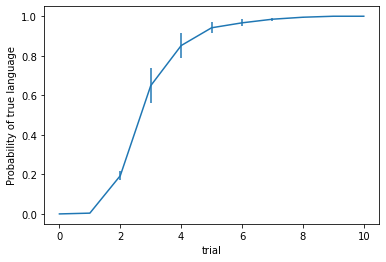

In [158]:
fig, ax = plt.subplots()
ax.errorbar(np.arange(len(means)), means, variances)
ax.set_xlabel('trial')
ax.set_ylabel('Probability of true language')
plt.show()

### Without considering negative evidence

In [136]:
index_true_language = (2,3)

In [159]:
histories = run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=False
)

IntProgress(value=0)

In [140]:
true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

In [141]:
means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

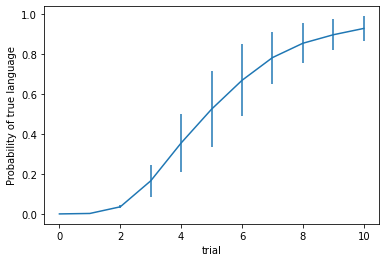

In [142]:
fig, ax = plt.subplots()
ax.errorbar(np.arange(len(means)), means, variances)
ax.set_xlabel('trial')
ax.set_ylabel('Probability of true language')
plt.show()